##### Copyright 2020 Google LLC.

In [124]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<a href="https://colab.research.google.com/github/google-research/simclr/blob/master/tf2/colabs/distillation_self_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [125]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated successfully.")

Authenticated successfully.


## SimCLR: A Simple Framework for Contrastive Learning of Visual Representations

This colab demonstrates how to load pretrained/finetuned SimCLR models from hub modules for distillation / self-training (without needing actual labels).

The checkpoints are accessible in the following Google Cloud Storage folders.

* Pretrained SimCLRv2 models with a linear classifier: [gs://simclr-checkpoints-tf2/simclrv2/pretrained](https://console.cloud.google.com/storage/browser/simclr-checkpoints-tf2/simclrv2/pretrained)
* Fine-tuned SimCLRv2 models on 1% of labels: [gs://simclr-checkpoints-tf2/simclrv2/finetuned_1pct](https://console.cloud.google.com/storage/browser/simclr-checkpoints-tf2/simclrv2/finetuned_1pct)
* Fine-tuned SimCLRv2 models on 10% of labels: [gs://simclr-checkpoints-tf2/simclrv2/finetuned_10pct](https://console.cloud.google.com/storage/browser/simclr-checkpoints-tf2/simclrv2/finetuned_10pct)
* Fine-tuned SimCLRv2 models on 100% of labels: [gs://simclr-checkpoints-tf2/simclrv2/finetuned_100pct](https://console.cloud.google.com/storage/browser/simclr-checkpoints-tf2/simclrv2/finetuned_100pct)
* Supervised models with the same architectures: [gs://simclr-checkpoints-tf2/simclrv2/pretrained](https://console.cloud.google.com/storage/browser/simclr-checkpoints-tf2/simclrv2/pretrained)

Use the corresponding checkpoint / hub-module paths for accessing the model. For example, to use a pre-trained model (with a linear classifier) with ResNet-152 (2x+SK), set the path to `gs://simclr-checkpoints-tf2/simclrv2/pretrained/r152_2x_sk1`.

In [126]:
import re
import numpy as np

import tensorflow.compat.v2 as tf
tf.compat.v1.enable_v2_behavior()
import tensorflow_hub as hub
import tensorflow_datasets as tfds

import matplotlib
import matplotlib.pyplot as plt

In [127]:
#@title Load class id to label text mapping (Fallback version)
# Hardcoded labels to ensure the notebook works without external downloads

imagenet_int_to_str = {
    0: "tench", 1: "goldfish", 2: "great white shark", 3: "tiger shark", 4: "hammerhead",
    970: "alp", 971: "bubble", 972: "cliff", 973: "coral reef", 974: "geyser",
    975: "lakeside", 976: "promontory", 977: "sandbar", 978: "seashore", 979: "valley",
    985: "daisy", 949: "strawberry", 950: "orange", 951: "lemon", 954: "banana"
}

# Populate missing indices with generic labels to avoid KeyErrors
for i in range(1000):
    if i not in imagenet_int_to_str:
        imagenet_int_to_str[i] = f"class_{i}"

tf_flowers_labels = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
print("Hardcoded fallback labels loaded successfully.")

Hardcoded fallback labels loaded successfully.


In [128]:
#@title Preprocessing functions from data_util.py in SimCLR repository (hidden).

FLAGS_color_jitter_strength = 0.3
CROP_PROPORTION = 0.875  # Standard for ImageNet.


def random_apply(func, p, x):
  """Randomly apply function func to x with probability p."""
  return tf.cond(
      tf.less(tf.random.uniform([], minval=0, maxval=1, dtype=tf.float32),
              tf.cast(p, tf.float32)),
      lambda: func(x),
      lambda: x)

def random_brightness(image, max_delta, impl='simclrv2'):
  """A multiplicative vs additive change of brightness."""
  if impl == 'simclrv2':
    factor = tf.random.uniform(
        [], tf.maximum(1.0 - max_delta, 0), 1.0 + max_delta)
    image = image * factor
  elif impl == 'simclrv1':
    image = random_brightness(image, max_delta=max_delta)
  else:
    raise ValueError('Unknown impl {} for random brightness.'.format(impl))
  return image


def to_grayscale(image, keep_channels=True):
  image = tf.image.rgb_to_grayscale(image)
  if keep_channels:
    image = tf.tile(image, [1, 1, 3])
  return image


def color_jitter(image,
                 strength,
                 random_order=True):
  """Distorts the color of the image.
  Args:
    image: The input image tensor.
    strength: the floating number for the strength of the color augmentation.
    random_order: A bool, specifying whether to randomize the jittering order.
  Returns:
    The distorted image tensor.
  """
  brightness = 0.8 * strength
  contrast = 0.8 * strength
  saturation = 0.8 * strength
  hue = 0.2 * strength
  if random_order:
    return color_jitter_rand(image, brightness, contrast, saturation, hue)
  else:
    return color_jitter_nonrand(image, brightness, contrast, saturation, hue)


def color_jitter_nonrand(image, brightness=0, contrast=0, saturation=0, hue=0):
  """Distorts the color of the image (jittering order is fixed).
  Args:
    image: The input image tensor.
    brightness: A float, specifying the brightness for color jitter.
    contrast: A float, specifying the contrast for color jitter.
    saturation: A float, specifying the saturation for color jitter.
    hue: A float, specifying the hue for color jitter.
  Returns:
    The distorted image tensor.
  """
  with tf.name_scope('distort_color'):
    def apply_transform(i, x, brightness, contrast, saturation, hue):
      """Apply the i-th transformation."""
      if brightness != 0 and i == 0:
        x = random_brightness(x, max_delta=brightness)
      elif contrast != 0 and i == 1:
        x = tf.image.random_contrast(
            x, lower=1-contrast, upper=1+contrast)
      elif saturation != 0 and i == 2:
        x = tf.image.random_saturation(
            x, lower=1-saturation, upper=1+saturation)
      elif hue != 0:
        x = tf.image.random_hue(x, max_delta=hue)
      return x

    for i in range(4):
      image = apply_transform(i, image, brightness, contrast, saturation, hue)
      image = tf.clip_by_value(image, 0., 1.)
    return image


def color_jitter_rand(image, brightness=0, contrast=0, saturation=0, hue=0):
  """Distorts the color of the image (jittering order is random).
  Args:
    image: The input image tensor.
    brightness: A float, specifying the brightness for color jitter.
    contrast: A float, specifying the contrast for color jitter.
    saturation: A float, specifying the saturation for color jitter.
    hue: A float, specifying the hue for color jitter.
  Returns:
    The distorted image tensor.
  """
  with tf.name_scope('distort_color'):
    def apply_transform(i, x):
      """Apply the i-th transformation."""
      def brightness_foo():
        if brightness == 0:
          return x
        else:
          return random_brightness(x, max_delta=brightness)
      def contrast_foo():
        if contrast == 0:
          return x
        else:
          return tf.image.random_contrast(x, lower=1-contrast, upper=1+contrast)
      def saturation_foo():
        if saturation == 0:
          return x
        else:
          return tf.image.random_saturation(
              x, lower=1-saturation, upper=1+saturation)
      def hue_foo():
        if hue == 0:
          return x
        else:
          return tf.image.random_hue(x, max_delta=hue)
      x = tf.cond(tf.less(i, 2),
                  lambda: tf.cond(tf.less(i, 1), brightness_foo, contrast_foo),
                  lambda: tf.cond(tf.less(i, 3), saturation_foo, hue_foo))
      return x

    perm = tf.random_shuffle(tf.range(4))
    for i in range(4):
      image = apply_transform(perm[i], image)
      image = tf.clip_by_value(image, 0., 1.)
    return image


def _compute_crop_shape(
    image_height, image_width, aspect_ratio, crop_proportion):
  """Compute aspect ratio-preserving shape for central crop.
  The resulting shape retains `crop_proportion` along one side and a proportion
  less than or equal to `crop_proportion` along the other side.
  Args:
    image_height: Height of image to be cropped.
    image_width: Width of image to be cropped.
    aspect_ratio: Desired aspect ratio (width / height) of output.
    crop_proportion: Proportion of image to retain along the less-cropped side.
  Returns:
    crop_height: Height of image after cropping.
    crop_width: Width of image after cropping.
  """
  image_width_float = tf.cast(image_width, tf.float32)
  image_height_float = tf.cast(image_height, tf.float32)

  def _requested_aspect_ratio_wider_than_image():
    crop_height = tf.cast(tf.math.rint(
        crop_proportion / aspect_ratio * image_width_float), tf.int32)
    crop_width = tf.cast(tf.math.rint(
        crop_proportion * image_width_float), tf.int32)
    return crop_height, crop_width

  def _image_wider_than_requested_aspect_ratio():
    crop_height = tf.cast(
        tf.math.rint(crop_proportion * image_height_float), tf.int32)
    crop_width = tf.cast(tf.math.rint(
        crop_proportion * aspect_ratio *
        image_height_float), tf.int32)
    return crop_height, crop_width

  return tf.cond(
      aspect_ratio > image_width_float / image_height_float,
      _requested_aspect_ratio_wider_than_image,
      _image_wider_than_requested_aspect_ratio)


def center_crop(image, height, width, crop_proportion):
  """Crops to center of image and rescales to desired size.
  Args:
    image: Image Tensor to crop.
    height: Height of image to be cropped.
    width: Width of image to be cropped.
    crop_proportion: Proportion of image to retain along the less-cropped side.
  Returns:
    A `height` x `width` x channels Tensor holding a central crop of `image`.
  """
  shape = tf.shape(image)
  image_height = shape[0]
  image_width = shape[1]
  crop_height, crop_width = _compute_crop_shape(
      image_height, image_width, height / width, crop_proportion)
  offset_height = ((image_height - crop_height) + 1) // 2
  offset_width = ((image_width - crop_width) + 1) // 2
  image = tf.image.crop_to_bounding_box(
      image, offset_height, offset_width, crop_height, crop_width)

  image = tf.compat.v1.image.resize_bicubic([image], [height, width])[0]

  return image


def distorted_bounding_box_crop(image,
                                bbox,
                                min_object_covered=0.1,
                                aspect_ratio_range=(0.75, 1.33),
                                area_range=(0.05, 1.0),
                                max_attempts=100,
                                scope=None):
  """Generates cropped_image using one of the bboxes randomly distorted.
  See `tf.image.sample_distorted_bounding_box` for more documentation.
  Args:
    image: `Tensor` of image data.
    bbox: `Tensor` of bounding boxes arranged `[1, num_boxes, coords]`
        where each coordinate is [0, 1) and the coordinates are arranged
        as `[ymin, xmin, ymax, xmax]`. If num_boxes is 0 then use the whole
        image.
    min_object_covered: An optional `float`. Defaults to `0.1`. The cropped
        area of the image must contain at least this fraction of any bounding
        box supplied.
    aspect_ratio_range: An optional list of `float`s. The cropped area of the
        image must have an aspect ratio = width / height within this range.
    area_range: An optional list of `float`s. The cropped area of the image
        must contain a fraction of the supplied image within in this range.
    max_attempts: An optional `int`. Number of attempts at generating a cropped
        region of the image of the specified constraints. After `max_attempts`
        failures, return the entire image.
    scope: Optional `str` for name scope.
  Returns:
    (cropped image `Tensor`, distorted bbox `Tensor`).
  """
  with tf.name_scope('distorted_bounding_box_crop'):
    shape = tf.shape(image)
    sample_distorted_bounding_box = tf.image.sample_distorted_bounding_box(
        shape,
        bounding_boxes=bbox,
        min_object_covered=min_object_covered,
        aspect_ratio_range=aspect_ratio_range,
        area_range=area_range,
        max_attempts=max_attempts,
        use_image_if_no_bounding_boxes=True)
    bbox_begin, bbox_size, _ = sample_distorted_bounding_box

    # Crop the image to the specified bounding box.
    offset_y, offset_x, _ = tf.unstack(bbox_begin)
    target_height, target_width, _ = tf.unstack(bbox_size)
    image = tf.image.crop_to_bounding_box(
        image, offset_y, offset_x, target_height, target_width)

    return image


def crop_and_resize(image, height, width):
  """Make a random crop and resize it to height `height` and width `width`.
  Args:
    image: Tensor representing the image.
    height: Desired image height.
    width: Desired image width.
  Returns:
    A `height` x `width` x channels Tensor holding a random crop of `image`.
  """
  bbox = tf.constant([0.0, 0.0, 1.0, 1.0], dtype=tf.float32, shape=[1, 1, 4])
  aspect_ratio = width / height
  image = distorted_bounding_box_crop(
      image,
      bbox,
      min_object_covered=0.1,
      aspect_ratio_range=(3. / 4 * aspect_ratio, 4. / 3. * aspect_ratio),
      area_range=(0.08, 1.0),
      max_attempts=100,
      scope=None)
  return tf.compat.v1.image.resize_bicubic([image], [height, width])[0]


def gaussian_blur(image, kernel_size, sigma, padding='SAME'):
  """Blurs the given image with separable convolution.
  Args:
    image: Tensor of shape [height, width, channels] and dtype float to blur.
    kernel_size: Integer Tensor for the size of the blur kernel. This is should
      be an odd number. If it is an even number, the actual kernel size will be
      size + 1.
    sigma: Sigma value for gaussian operator.
    padding: Padding to use for the convolution. Typically 'SAME' or 'VALID'.
  Returns:
    A Tensor representing the blurred image.
  """
  radius = tf.to_int32(kernel_size / 2)
  kernel_size = radius * 2 + 1
  x = tf.to_float(tf.range(-radius, radius + 1))
  blur_filter = tf.exp(
      -tf.pow(x, 2.0) / (2.0 * tf.pow(tf.to_float(sigma), 2.0)))
  blur_filter /= tf.reduce_sum(blur_filter)
  # One vertical and one horizontal filter.
  blur_v = tf.reshape(blur_filter, [kernel_size, 1, 1, 1])
  blur_h = tf.reshape(blur_filter, [1, kernel_size, 1, 1])
  num_channels = tf.shape(image)[-1]
  blur_h = tf.tile(blur_h, [1, 1, num_channels, 1])
  blur_v = tf.tile(blur_v, [1, 1, num_channels, 1])
  expand_batch_dim = image.shape.ndims == 3
  if expand_batch_dim:
    # Tensorflow requires batched input to convolutions, which we can fake with
    # an extra dimension.
    image = tf.expand_dims(image, axis=0)
  blurred = tf.nn.depthwise_conv2d(
      image, blur_h, strides=[1, 1, 1, 1], padding=padding)
  blurred = tf.nn.depthwise_conv2d(
      blurred, blur_v, strides=[1, 1, 1, 1], padding=padding)
  if expand_batch_dim:
    blurred = tf.squeeze(blurred, axis=0)
  return blurred


def random_crop_with_resize(image, height, width, p=1.0):
  """Randomly crop and resize an image.
  Args:
    image: `Tensor` representing an image of arbitrary size.
    height: Height of output image.
    width: Width of output image.
    p: Probability of applying this transformation.
  Returns:
    A preprocessed image `Tensor`.
  """
  def _transform(image):  # pylint: disable=missing-docstring
    image = crop_and_resize(image, height, width)
    return image
  return random_apply(_transform, p=p, x=image)


def random_color_jitter(image, p=1.0):
  def _transform(image):
    color_jitter_t = functools.partial(
        color_jitter, strength=FLAGS_color_jitter_strength)
    image = random_apply(color_jitter_t, p=0.8, x=image)
    return random_apply(to_grayscale, p=0.2, x=image)
  return random_apply(_transform, p=p, x=image)


def random_blur(image, height, width, p=1.0):
  """Randomly blur an image.
  Args:
    image: `Tensor` representing an image of arbitrary size.
    height: Height of output image.
    width: Width of output image.
    p: probability of applying this transformation.
  Returns:
    A preprocessed image `Tensor`.
  """
  del width
  def _transform(image):
    sigma = tf.random.uniform([], 0.1, 2.0, dtype=tf.float32)
    return gaussian_blur(
        image, kernel_size=height//10, sigma=sigma, padding='SAME')
  return random_apply(_transform, p=p, x=image)


def batch_random_blur(images_list, height, width, blur_probability=0.5):
  """Apply efficient batch data transformations.
  Args:
    images_list: a list of image tensors.
    height: the height of image.
    width: the width of image.
    blur_probability: the probaility to apply the blur operator.
  Returns:
    Preprocessed feature list.
  """
  def generate_selector(p, bsz):
    shape = [bsz, 1, 1, 1]
    selector = tf.cast(
        tf.less(tf.random.uniform(shape, 0, 1, dtype=tf.float32), p),
        tf.float32)
    return selector

  new_images_list = []
  for images in images_list:
    images_new = random_blur(images, height, width, p=1.)
    selector = generate_selector(blur_probability, tf.shape(images)[0])
    images = images_new * selector + images * (1 - selector)
    images = tf.clip_by_value(images, 0., 1.)
    new_images_list.append(images)

  return new_images_list


def preprocess_for_train(image, height, width,
                         color_distort=True, crop=True, flip=True):
  """Preprocesses the given image for training.
  Args:
    image: `Tensor` representing an image of arbitrary size.
    height: Height of output image.
    width: Width of output image.
    color_distort: Whether to apply the color distortion.
    crop: Whether to crop the image.
    flip: Whether or not to flip left and right of an image.
  Returns:
    A preprocessed image `Tensor`.
  """
  if crop:
    image = random_crop_with_resize(image, height, width)
  if flip:
    image = tf.image.random_flip_left_right(image)
  if color_distort:
    image = random_color_jitter(image)
  image = tf.reshape(image, [height, width, 3])
  image = tf.clip_by_value(image, 0., 1.)
  return image


def preprocess_for_eval(image, height, width, crop=True):
  """Preprocesses the given image for evaluation.
  Args:
    image: `Tensor` representing an image of arbitrary size.
    height: Height of output image.
    width: Width of output image.
    crop: Whether or not to (center) crop the test images.
  Returns:
    A preprocessed image `Tensor`.
  """
  if crop:
    image = center_crop(image, height, width, crop_proportion=CROP_PROPORTION)
  image = tf.reshape(image, [height, width, 3])
  image = tf.clip_by_value(image, 0., 1.)
  return image


def preprocess_image(image, height, width, is_training=False,
                     color_distort=True, test_crop=True):
  """Preprocesses the given image.
  Args:
    image: `Tensor` representing an image of arbitrary size.
    height: Height of output image.
    width: Width of output image.
    is_training: `bool` for whether the preprocessing is for training.
    color_distort: whether to apply the color distortion.
    test_crop: whether or not to extract a central crop of the images
        (as for standard ImageNet evaluation) during the evaluation.
  Returns:
    A preprocessed image `Tensor` of range [0, 1].
  """
  image = tf.image.convert_image_dtype(image, dtype=tf.float32)
  if is_training:
    return preprocess_for_train(image, height, width, color_distort)
  else:
    return preprocess_for_eval(image, height, width, test_crop)

In [129]:
EETA_DEFAULT = 0.001

class LARSOptimizer(tf.keras.optimizers.Optimizer):
  """Layer-wise Adaptive Rate Scaling for large batch training."""

  def __init__(self, learning_rate, momentum=0.9, use_nesterov=False, weight_decay=0.0, exclude_from_weight_decay=None, exclude_from_layer_adaptation=None, classic_momentum=True, eeta=EETA_DEFAULT, name="LARSOptimizer", **kwargs):
    super(LARSOptimizer, self).__init__(learning_rate=learning_rate, name=name, **kwargs)
    self.momentum = momentum
    self.weight_decay = weight_decay
    self.use_nesterov = use_nesterov
    self.classic_momentum = classic_momentum
    self.eeta = eeta
    self.exclude_from_weight_decay = exclude_from_weight_decay
    self.exclude_from_layer_adaptation = exclude_from_layer_adaptation if exclude_from_layer_adaptation else exclude_from_weight_decay

  def build(self, var_list):
    """Initialize optimizer slots in Keras 3 style."""
    if self.built:
      return
    super().build(var_list)
    self.moment_slots = {}
    for v in var_list:
      # Use add_variable_from_reference to create the slot and store it in a dict
      self.moment_slots[self._get_variable_index(v)] = self.add_variable_from_reference(v, "moment")

  def update_step(self, gradient, variable, learning_rate):
    """Update step for a single variable."""
    var_key = str(variable.name)
    lr = tf.cast(learning_rate, variable.dtype)
    gradient = tf.cast(gradient, variable.dtype)

    # Access the slot variable from our mapping using the internal index
    moment = self.moment_slots[self._get_variable_index(variable)]

    if self._use_weight_decay(var_key):
      gradient = gradient + tf.cast(self.weight_decay, variable.dtype) * variable

    if self.classic_momentum:
      trust_ratio = 1.0
      if self._do_layer_adaptation(var_key):
        w_norm = tf.norm(variable, ord=2)
        g_norm = tf.norm(gradient, ord=2)
        trust_ratio = tf.where(tf.greater(w_norm, 0), tf.where(tf.greater(g_norm, 0), (tf.cast(self.eeta, variable.dtype) * w_norm / g_norm), 1.0), 1.0)

      scaled_lr = lr * trust_ratio
      next_moment = tf.cast(self.momentum, variable.dtype) * moment + scaled_lr * gradient
      update = tf.cast(self.momentum, variable.dtype) * next_moment + scaled_lr * gradient if self.use_nesterov else next_moment
      variable.assign_sub(update)
      moment.assign(next_moment)
    else:
      update = tf.cast(self.momentum, variable.dtype) * moment + gradient
      trust_ratio = 1.0
      if self._do_layer_adaptation(var_key):
        w_norm = tf.norm(variable, ord=2)
        v_norm = tf.norm(update, ord=2)
        trust_ratio = tf.where(tf.greater(w_norm, 0), tf.where(tf.greater(v_norm, 0), (tf.cast(self.eeta, variable.dtype) * w_norm / v_norm), 1.0), 1.0)

      scaled_lr = trust_ratio * lr
      variable.assign_sub(scaled_lr * update)
      moment.assign(update)

  def _use_weight_decay(self, param_name):
    if not self.weight_decay: return False
    if self.exclude_from_weight_decay:
      for r in self.exclude_from_weight_decay:
        if re.search(str(r), str(param_name)) is not None: return False
    return True

  def _do_layer_adaptation(self, param_name):
    if self.exclude_from_layer_adaptation:
      for r in self.exclude_from_layer_adaptation:
        if re.search(str(r), str(param_name)) is not None: return False
    return True

In [130]:
#@title Defining the student architecture and distillation loss.

def add_kd_loss(student_logits, teacher_logits, temperature):
  """Compute distillation loss."""
  teacher_probs = tf.nn.softmax(teacher_logits / temperature)
  kd_loss = tf.reduce_mean(temperature**2 * tf.nn.softmax_cross_entropy_with_logits(
      teacher_probs, student_logits / temperature))
  return kd_loss

# Define a small student ConvNet
def build_student_model():
  student_model = tf.keras.models.Sequential()
  student_model.add(tf.keras.layers.Conv2D(64, (3, 3), input_shape=(224, 224, 3)))
  student_model.add(tf.keras.layers.BatchNormalization())
  student_model.add(tf.keras.layers.Activation('relu'))
  student_model.add(tf.keras.layers.MaxPooling2D((4, 4)))
  student_model.add(tf.keras.layers.Conv2D(128, (3, 3)))
  student_model.add(tf.keras.layers.BatchNormalization())
  student_model.add(tf.keras.layers.Activation('relu'))
  student_model.add(tf.keras.layers.MaxPooling2D((4, 4)))
  student_model.add(tf.keras.layers.Conv2D(256, (3, 3)))
  student_model.add(tf.keras.layers.BatchNormalization())
  student_model.add(tf.keras.layers.Activation('relu'))
  student_model.add(tf.keras.layers.GlobalAveragePooling2D())
  student_model.add(tf.keras.layers.Dense(512, activation='relu'))
  # Updated to 2048 to match the teacher's feature vector dimension
  student_model.add(tf.keras.layers.Dense(2048))
  return student_model

In [131]:
#@title Load tensorflow datasets: we use tensorflow flower dataset as an example

batch_size = 16
dataset_name = 'tf_flowers'

tfds_dataset, tfds_info = tfds.load(
    dataset_name, split='train', with_info=True)
num_images = tfds_info.splits['train'].num_examples
num_classes = tfds_info.features['label'].num_classes

def _preprocess(x):
  x['image'] = preprocess_image(
      x['image'], 224, 224, is_training=True, color_distort=False)
  return x
ds = tfds_dataset.map(_preprocess).batch(batch_size)

In [132]:
class Model(tf.keras.Model):
  def __init__(self, hub_url):
    super(Model, self).__init__()
    self.teacher_model = hub.KerasLayer(hub_url, trainable=False)
    self.student_model = build_student_model()
    # Use 'self.optimizer' property so Keras 3 manages build/binding automatically
    self.optimizer = LARSOptimizer(
        learning_rate=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay,
        exclude_from_weight_decay=['batch_normalization', 'bias'])

  def call(self, x, training=False):
    image_batch = x['image'] if isinstance(x, dict) else x
    return self.student_model(image_batch, training=training)

  def train_step(self, data):
    image_batch = data['image'] if isinstance(data, dict) else data

    with tf.GradientTape() as tape:
      teacher_logits = self.teacher_model(image_batch, training=False)
      student_logits = self.student_model(image_batch, training=True)
      loss = add_kd_loss(student_logits, teacher_logits, temperature)

    trainable_vars = self.student_model.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    # apply_gradients will now trigger the build() call correctly internally
    self.optimizer.apply_gradients(zip(gradients, trainable_vars))

    return {"loss": loss, "teacher_logits": teacher_logits, "student_logits": student_logits}

hub_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5"
model = Model(hub_url)
print("Optimizer and Model updated for robust Keras 3 variable binding.")

Optimizer and Model updated for robust Keras 3 variable binding.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
# Re-initialize fresh model with fixed optimizer
hub_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5"
model = Model(hub_url)

print("Starting training loop...")
iterator = iter(ds)
total_steps = 10

for it in range(total_steps):
  try:
    batch = next(iterator)
    results = model.train_step(batch)

    loss = results['loss']
    teacher_logits = results['teacher_logits']
    student_logits = results['student_logits']
    image = batch['image']

    labels = np.argmax(teacher_logits.numpy(), axis=-1)
    pred = np.argmax(student_logits.numpy(), axis=-1)

    correct = np.sum(pred == labels)
    print(f"[Iter {it+1}] Loss: {float(loss):.4f} Top 1 Match: {correct/labels.size:.2f}")
  except StopIteration:
    break

Starting training loop...
[Iter 1] Loss: 7.6303 Top 1 Match: 0.00
[Iter 2] Loss: 7.1077 Top 1 Match: 0.38
[Iter 3] Loss: 6.5706 Top 1 Match: 0.25
[Iter 4] Loss: 5.9617 Top 1 Match: 0.19
[Iter 5] Loss: 5.2015 Top 1 Match: 0.31
[Iter 6] Loss: 6.1455 Top 1 Match: 0.19
[Iter 7] Loss: 6.6004 Top 1 Match: 0.12
[Iter 8] Loss: 5.9180 Top 1 Match: 0.19
[Iter 9] Loss: 4.9690 Top 1 Match: 0.12
[Iter 10] Loss: 5.6585 Top 1 Match: 0.06


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Recording training metrics...
Step 5/15 - Loss: 7.7745 - Acc: 0.19
Step 10/15 - Loss: 5.6616 - Acc: 0.19
Step 15/15 - Loss: 5.9080 - Acc: 0.19


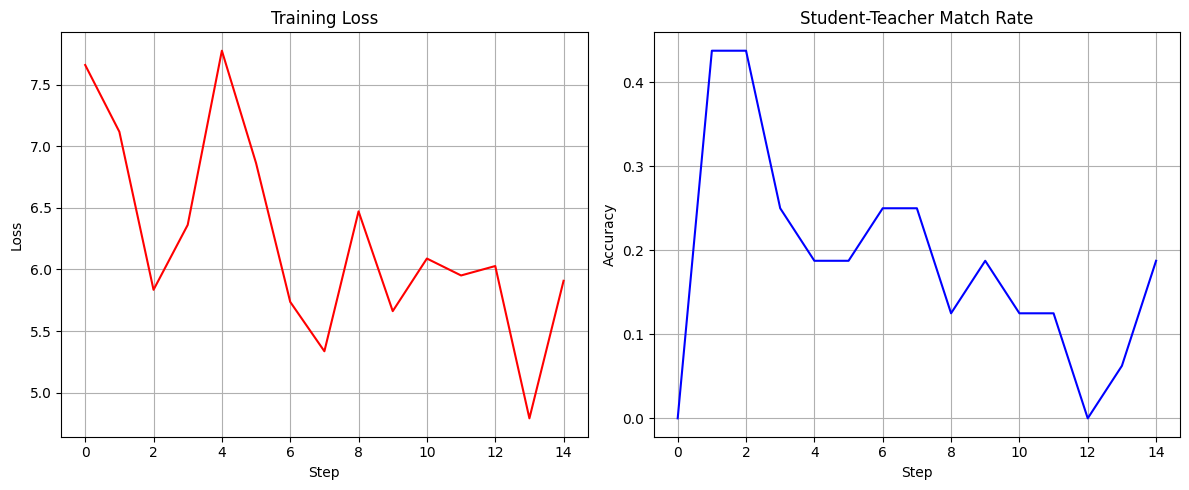

In [136]:
import matplotlib.pyplot as plt

# We'll re-run training and record history for better plotting
# (The previous variables only held the last iteration's values)

history = {'loss': [], 'accuracy': []}
model = Model(hub_url)
iterator = iter(ds)
total_steps = 15

print("Recording training metrics...")
for it in range(total_steps):
    try:
        batch = next(iterator)
        results = model.train_step(batch)

        # Record metrics
        loss_val = float(results['loss'])
        teacher_logits = results['teacher_logits'].numpy()
        student_logits = results['student_logits'].numpy()

        labels = np.argmax(teacher_logits, axis=-1)
        pred = np.argmax(student_logits, axis=-1)
        acc = np.sum(pred == labels) / labels.size

        history['loss'].append(loss_val)
        history['accuracy'].append(acc)

        if (it + 1) % 5 == 0:
            print(f"Step {it+1}/{total_steps} - Loss: {loss_val:.4f} - Acc: {acc:.2f}")
    except StopIteration:
        break

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Distillation Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Top-1 Match', color='blue')
plt.title('Student-Teacher Match Rate')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

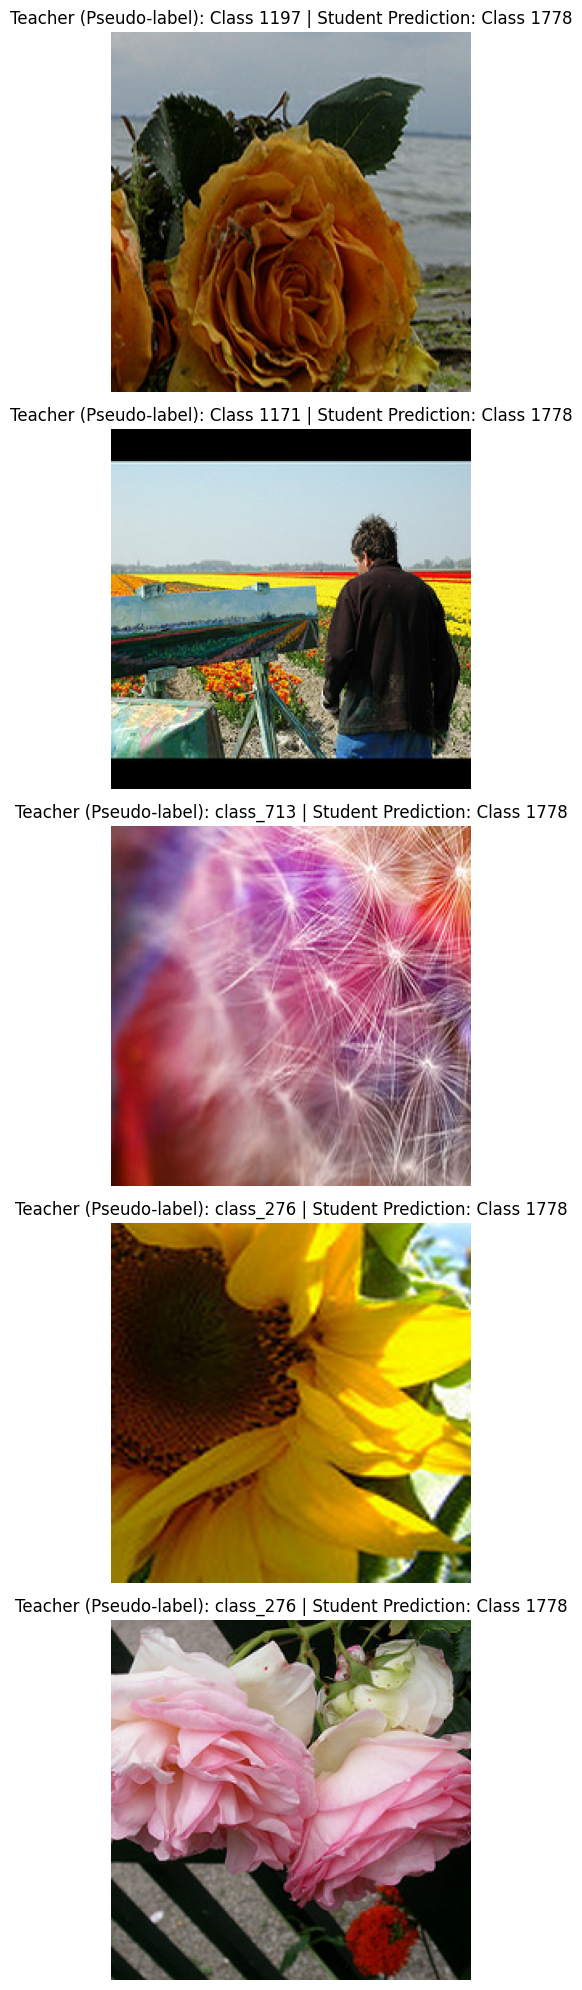

In [135]:
# Visualize the results from the last batch
if 'image' in locals():
  fig, axes = plt.subplots(5, 1, figsize=(15, 20))
  for i in range(5):
    axes[i].imshow(image[i])
    true_text = imagenet_int_to_str.get(labels[i], f"Class {labels[i]}")
    pred_text = imagenet_int_to_str.get(pred[i], f"Class {pred[i]}")
    axes[i].axis('off')
    axes[i].set_title(f'Teacher (Pseudo-label): {true_text} | Student Prediction: {pred_text}')
  plt.tight_layout()
  plt.show()
else:
  print("No training data found. Please run the training loop cell first.")